<a href="https://colab.research.google.com/github/jrivasgo/TFG-Algoritmos-de-clasificacio-de-radiografias-de-torax/blob/main/Modelo_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
gpus = tf.config.list_physical_devices("GPU")

print("GPUs disponibles:")

for gpu in gpus:
    print(gpu)

if len(gpus) == 0:
    print("No se ha detectado GPU.")
else:
    print("GPU detectada correctamente.")

GPUs disponibles:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU detectada correctamente.


Rutas y variables globales

In [ ]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

RUTA_DATASET_ORIGINAL = Path(
    "/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset"
)

RUTA_TRABAJO = Path("/content/datos_radiografias_resnet50_preentrenada")
RUTA_DATASET_PROCESADO = RUTA_TRABAJO / "procesado"

RUTA_CARPETA_MODELOS = Path(
    "/content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset"
)

RUTA_CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)

RUTA_MEJOR_MODELO = (
    RUTA_CARPETA_MODELOS / "mejor_modelo_resnet50_preentrenada_1dataset.keras"
)

RUTA_MODELO_FINAL = (
    RUTA_CARPETA_MODELOS / "modelo_final_resnet50_preentrenada_1dataset.keras"
)

RUTA_METADATA = (
    RUTA_CARPETA_MODELOS / "metadata_resnet50_preentrenada_1dataset.csv"
)

CLASES = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

# ResNet50 preentrenada suele usarse con 224x224.
TAMANO_IMAGEN = (224, 224)

TAMANO_LOTE = 16
EPOCAS = 30

EXTENSIONES_VALIDAS = {".png", ".jpg", ".jpeg"}

PORCENTAJE_ENTRENAMIENTO = 0.70
PORCENTAJE_VALIDACION = 0.15
PORCENTAJE_TEST = 0.15

MAX_IMAGENES_POR_CLASE = None

USAR_AUMENTO_DATOS = True

print("Dataset usado:")
print(RUTA_DATASET_ORIGINAL)

print("\nModelos guardados en:")
print(RUTA_CARPETA_MODELOS)

print("\nMejor modelo:")
print(RUTA_MEJOR_MODELO)

print("\nModelo final:")
print(RUTA_MODELO_FINAL)

print("\nClases:")
print(CLASES)

Dataset usado:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Modelos guardados en:
/content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset

Mejor modelo:
/content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/mejor_modelo_resnet50_preentrenada_1dataset.keras

Modelo final:
/content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/modelo_final_resnet50_preentrenada_1dataset.keras

Clases:
['COVID', 'Normal', 'Viral Pneumonia']


Comporbaciones de dataset

In [ ]:
if not RUTA_DATASET_ORIGINAL.exists():
    raise FileNotFoundError(
        f"No existe la ruta del dataset: {RUTA_DATASET_ORIGINAL}"
    )

print("Contenido del dataset:")

for elemento in RUTA_DATASET_ORIGINAL.iterdir():
    print("-", elemento.name)

print("\nConteo inicial de imágenes por clase:")

for nombre_clase in CLASES:
    ruta_clase = RUTA_DATASET_ORIGINAL / nombre_clase

    if not ruta_clase.exists():
        print(nombre_clase, ": NO EXISTE")
        continue

    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    imagenes = [
        archivo for archivo in ruta_busqueda.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        and "mask" not in str(archivo).lower()
        and "masks" not in str(archivo).lower()
    ]

    print(nombre_clase, ":", len(imagenes))

Contenido del dataset:
- COVID
- COVID.metadata.xlsx
- Lung_Opacity
- Lung_Opacity.metadata.xlsx
- Normal.metadata.xlsx
- Normal
- Viral Pneumonia
- Viral Pneumonia.metadata.xlsx
- README.md.txt

Conteo inicial de imágenes por clase:
COVID : 3616
Normal : 10192
Viral Pneumonia : 1345


Funciones auxiliares, una para dividir las imagenes en clases y la otra para reiniciar la carpeta

In [ ]:
def reiniciar_carpeta(ruta: Path):
    if ruta.exists():
        shutil.rmtree(ruta)

    ruta.mkdir(parents=True, exist_ok=True)


def listar_imagenes_clase(ruta_clase: Path):
    ruta_imagenes = ruta_clase / "images"

    if ruta_imagenes.exists():
        ruta_busqueda = ruta_imagenes
    else:
        ruta_busqueda = ruta_clase

    imagenes = [
        archivo for archivo in ruta_busqueda.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        and "mask" not in str(archivo).lower()
        and "masks" not in str(archivo).lower()
    ]

    return imagenes

Particion de las imagenes (70 15 15)

In [ ]:
inicio_particionado = time.time()

reiniciar_carpeta(RUTA_DATASET_PROCESADO)

for particion in ["entrenamiento", "validacion", "test"]:
    for nombre_clase in CLASES:
        ruta_destino = RUTA_DATASET_PROCESADO / particion / nombre_clase
        ruta_destino.mkdir(parents=True, exist_ok=True)


registros_metadata = []

for nombre_clase in CLASES:
    ruta_clase = RUTA_DATASET_ORIGINAL / nombre_clase

    if not ruta_clase.exists():
        raise FileNotFoundError(f"No existe la carpeta de clase: {ruta_clase}")

    imagenes = listar_imagenes_clase(ruta_clase)

    if len(imagenes) == 0:
        raise ValueError(f"No se encontraron imágenes para la clase: {nombre_clase}")

    if (
        MAX_IMAGENES_POR_CLASE is not None
        and len(imagenes) > MAX_IMAGENES_POR_CLASE
    ):
        random.shuffle(imagenes)
        imagenes = imagenes[:MAX_IMAGENES_POR_CLASE]

    imagenes_entrenamiento, imagenes_temporales = train_test_split(
        imagenes,
        test_size=(1 - PORCENTAJE_ENTRENAMIENTO),
        random_state=SEMILLA,
        shuffle=True
    )

    imagenes_validacion, imagenes_test = train_test_split(
        imagenes_temporales,
        test_size=(
            PORCENTAJE_TEST
            / (PORCENTAJE_VALIDACION + PORCENTAJE_TEST)
        ),
        random_state=SEMILLA,
        shuffle=True
    )

    particiones = {
        "entrenamiento": imagenes_entrenamiento,
        "validacion": imagenes_validacion,
        "test": imagenes_test
    }

    for nombre_particion, lista_imagenes in particiones.items():
        print(
            f"\nCopiando {nombre_clase} - {nombre_particion}: "
            f"{len(lista_imagenes)} imágenes",
            flush=True
        )

        for indice, imagen in enumerate(lista_imagenes):
            nombre_clase_limpio = nombre_clase.replace(" ", "_")
            nombre_original_limpio = imagen.name.replace(" ", "_")

            nuevo_nombre = (
                f"{nombre_clase_limpio}_"
                f"{indice}_"
                f"{nombre_original_limpio}"
            )

            destino = (
                RUTA_DATASET_PROCESADO
                / nombre_particion
                / nombre_clase
                / nuevo_nombre
            )

            shutil.copyfile(imagen, destino)

            registros_metadata.append({
                "particion": nombre_particion,
                "clase": nombre_clase,
                "ruta_original": str(imagen),
                "ruta_procesada": str(destino)
            })

            if (indice + 1) % 500 == 0 or (indice + 1) == len(lista_imagenes):
                tiempo_transcurrido = time.time() - inicio_particionado

                print(
                    f"{nombre_clase} - {nombre_particion}: "
                    f"{indice + 1}/{len(lista_imagenes)} copiadas | "
                    f"Tiempo: {tiempo_transcurrido / 60:.2f} min",
                    flush=True
                )

    print(f"\nClase: {nombre_clase}")
    print("  Total usado:", len(imagenes))
    print("  Entrenamiento:", len(imagenes_entrenamiento))
    print("  Validación:", len(imagenes_validacion))
    print("  Test:", len(imagenes_test))


df_metadata = pd.DataFrame(registros_metadata)

df_metadata.to_csv(RUTA_METADATA, index=False)

print("\nMetadata guardada en:")
print(RUTA_METADATA)

print("\nTiempo total de particionado:")
print(f"{(time.time() - inicio_particionado) / 60:.2f} minutos")


Copiando COVID - entrenamiento: 2531 imágenes
COVID - entrenamiento: 500/2531 copiadas | Tiempo: 1.48 min
COVID - entrenamiento: 1000/2531 copiadas | Tiempo: 1.49 min
COVID - entrenamiento: 1500/2531 copiadas | Tiempo: 1.51 min
COVID - entrenamiento: 2000/2531 copiadas | Tiempo: 1.53 min
COVID - entrenamiento: 2500/2531 copiadas | Tiempo: 1.54 min
COVID - entrenamiento: 2531/2531 copiadas | Tiempo: 1.54 min

Copiando COVID - validacion: 542 imágenes
COVID - validacion: 500/542 copiadas | Tiempo: 1.56 min
COVID - validacion: 542/542 copiadas | Tiempo: 1.56 min

Copiando COVID - test: 543 imágenes
COVID - test: 500/543 copiadas | Tiempo: 1.58 min
COVID - test: 543/543 copiadas | Tiempo: 1.58 min

Clase: COVID
  Total usado: 3616
  Entrenamiento: 2531
  Validación: 542
  Test: 543

Copiando Normal - entrenamiento: 7134 imágenes
Normal - entrenamiento: 500/7134 copiadas | Tiempo: 5.18 min
Normal - entrenamiento: 1000/7134 copiadas | Tiempo: 5.20 min
Normal - entrenamiento: 1500/7134 copia

Comprobamos particiones

In [ ]:
for particion in ["entrenamiento", "validacion", "test"]:
    print("\nPartición:", particion)

    for nombre_clase in CLASES:
        ruta = RUTA_DATASET_PROCESADO / particion / nombre_clase

        imagenes = [
            archivo for archivo in ruta.iterdir()
            if archivo.is_file()
            and archivo.suffix.lower() in EXTENSIONES_VALIDAS
        ]

        print(nombre_clase, ":", len(imagenes))


print("\nDistribución general:")

df_metadata = pd.read_csv(RUTA_METADATA)

distribucion = (
    df_metadata
    .groupby(["particion", "clase"])
    .size()
    .reset_index(name="cantidad")
)

display(distribucion)


Partición: entrenamiento
COVID : 2531
Normal : 7134
Viral Pneumonia : 941

Partición: validacion
COVID : 542
Normal : 1529
Viral Pneumonia : 202

Partición: test
COVID : 543
Normal : 1529
Viral Pneumonia : 202

Distribución general:


,particion,clase,cantidad
0,entrenamiento,COVID,2531
1,entrenamiento,Normal,7134
2,entrenamiento,Viral Pneumonia,941
3,test,COVID,543
4,test,Normal,1529
5,test,Viral Pneumonia,202
6,validacion,COVID,542
7,validacion,Normal,1529
8,validacion,Viral Pneumonia,202


Cargamos el dataset con las subdivisiones aplicadas

In [ ]:
dataset_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "entrenamiento"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="rgb",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=True,
    seed=SEMILLA
)

dataset_validacion = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "validacion"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="rgb",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=False
)

dataset_test = tf.keras.utils.image_dataset_from_directory(
    str(RUTA_DATASET_PROCESADO / "test"),
    labels="inferred",
    label_mode="int",
    class_names=CLASES,
    color_mode="rgb",
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE,
    shuffle=False
)

print("Clases detectadas:", dataset_entrenamiento.class_names)

Found 10606 files belonging to 3 classes.
Found 2273 files belonging to 3 classes.
Found 2274 files belonging to 3 classes.
Clases detectadas: ['COVID', 'Normal', 'Viral Pneumonia']


Comporbamos un lote de entre los que esta subdividida las imagenes

In [ ]:
for imagenes_ejemplo, etiquetas_ejemplo in dataset_entrenamiento.take(1):
    print("Forma del lote de imágenes:", imagenes_ejemplo.shape)
    print("Forma del lote de etiquetas:", etiquetas_ejemplo.shape)
    print("Tipo de dato de las imágenes:", imagenes_ejemplo.dtype)
    print("Primeras etiquetas:", etiquetas_ejemplo.numpy()[:10])

Forma del lote de imágenes: (16, 224, 224, 3)
Forma del lote de etiquetas: (16,)
Tipo de dato de las imágenes: <dtype: 'float32'>
Primeras etiquetas: [0 1 0 0 0 1 0 1 0 1]


Asignamos pesos, en este caso, balanceados

In [ ]:
etiquetas_entrenamiento = []

for _, etiquetas in dataset_entrenamiento.unbatch():
    etiquetas_entrenamiento.append(int(etiquetas.numpy()))

etiquetas_entrenamiento = np.array(etiquetas_entrenamiento)

clases_numericas = np.unique(etiquetas_entrenamiento)

pesos_clases_array = compute_class_weight(
    class_weight="balanced",
    classes=clases_numericas,
    y=etiquetas_entrenamiento
)

pesos_clases = {
    int(clase): float(peso)
    for clase, peso in zip(clases_numericas, pesos_clases_array)
}

print("Pesos de clase:", pesos_clases)

print("\nDistribución de entrenamiento:")

for indice, nombre_clase in enumerate(CLASES):
    cantidad = np.sum(etiquetas_entrenamiento == indice)
    print(indice, "-", nombre_clase, ":", cantidad, "imágenes")

Pesos de clase: {0: 1.3968128539444225, 1: 0.49556116250817683, 2: 3.756996103436061}

Distribución de entrenamiento:
0 - COVID : 2531 imágenes
1 - Normal : 7134 imágenes
2 - Viral Pneumonia : 941 imágenes


In [ ]:
AUTOAJUSTE = tf.data.AUTOTUNE

dataset_entrenamiento = dataset_entrenamiento.prefetch(AUTOAJUSTE)
dataset_validacion = dataset_validacion.prefetch(AUTOAJUSTE)
dataset_test = dataset_test.prefetch(AUTOAJUSTE)

Se realiza el preprocesado que necesita resnet para tratar los datos

In [ ]:
@tf.keras.utils.register_keras_serializable(package="TFG")
class PreprocesadoResNet50(layers.Layer):
    """
    Aplica el preprocesado oficial de ResNet50.

    No divide entre 255.
    ResNet50 preprocess_input convierte RGB a BGR y centra los canales
    con los valores usados en ImageNet.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, entradas):
        entradas = tf.cast(entradas, tf.float32)
        return preprocess_input(entradas)

    def get_config(self):
        config = super().get_config()
        return config

Hacemos un aumento de datos suave

In [ ]:
aumento_datos = tf.keras.Sequential(
    [
        layers.RandomRotation(0.015),
        layers.RandomZoom(0.03),
        layers.RandomTranslation(0.02, 0.02),
    ],
    name="aumento_datos_suave"
)

Creamos el modelo ResNet50 preeentrenado

In [ ]:
def construir_modelo(numero_clases):
    entradas = layers.Input(
        shape=(TAMANO_IMAGEN[0], TAMANO_IMAGEN[1], 3),
        name="entrada_rgb"
    )

    x = entradas

    if USAR_AUMENTO_DATOS:
        x = aumento_datos(x)

    x = PreprocesadoResNet50(
        name="preprocesado_resnet50"
    )(x)

    base_resnet50 = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(TAMANO_IMAGEN[0], TAMANO_IMAGEN[1], 3)
    )

    base_resnet50.trainable = False

    x = base_resnet50(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        0.4,
        name="dropout_256"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="dense_64"
    )(x)

    x = layers.Dropout(
        0.25,
        name="dropout_64"
    )(x)

    salida = layers.Dense(
        numero_clases,
        activation="softmax",
        name="salida_clasificacion"
    )(x)

    modelo = Model(
        inputs=entradas,
        outputs=salida,
        name="modelo_resnet50_preentrenada_1dataset"
    )

    return modelo

Se crea y compila el modelo y se ven el resumen de lo que aplicamos

In [ ]:
modelo = construir_modelo(numero_clases=len(CLASES))

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "modelo_resnet50_preentrenada_1dataset"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_rgb (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento_datos_suave             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocesado_resnet50           │ (None, 224, 224, 3)    │             0 │
│ (PreprocesadoResNet50)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_clasificacion (Dense)    │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,128,899 (92.04 MB)

 Trainable params: 541,187 (2.06 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Callbacks

In [ ]:
callbacks_entrenamiento = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath=str(RUTA_MEJOR_MODELO),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

Realizamos el entrenamiento

In [ ]:
historial = modelo.fit(
    dataset_entrenamiento,
    validation_data=dataset_validacion,
    epochs=EPOCAS,
    callbacks=callbacks_entrenamiento,
    class_weight=pesos_clases
)

Epoch 1/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6723 - loss: 0.6701
Epoch 1: val_loss improved from None to 0.26441, saving model to /content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/mejor_modelo_resnet50_preentrenada_1dataset.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/mejor_modelo_resnet50_preentrenada_1dataset.keras
663/663 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.7579 - loss: 0.4959 - val_accuracy: 0.9037 - val_loss: 0.2644 - learning_rate: 1.0000e-04
Epoch 2/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8493 - loss: 0.3059
Epoch 2: val_loss improved from 0.26441 to 0.21500, saving model to /content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/mejor_modelo_resnet50_preentrenada_1dataset.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/mejor_modelo_resnet50_preentrenada_1dataset.keras
663/663 

Vemos las graficas comparando el proceso de entrenamiento del algoritmo

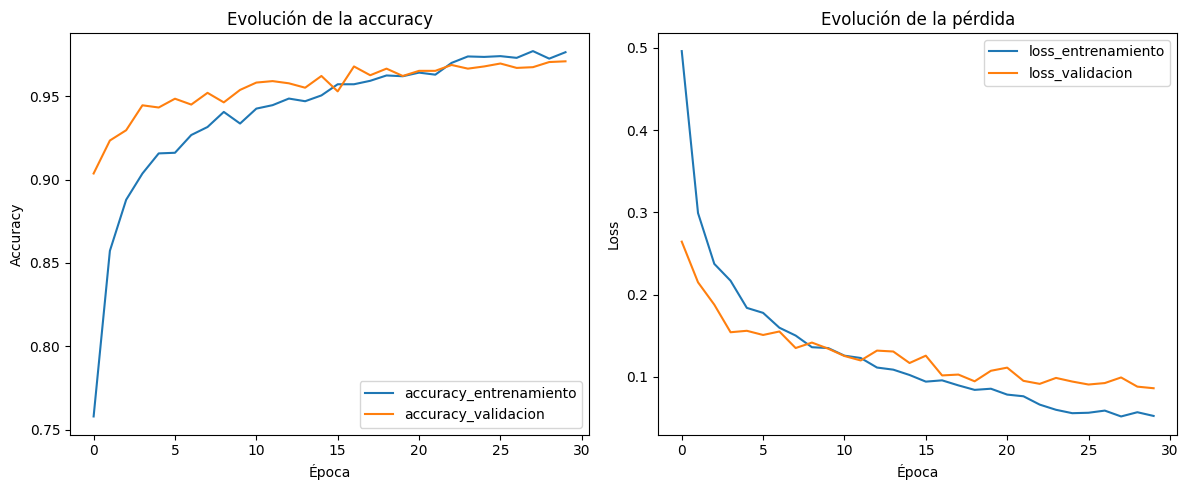

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historial.history["accuracy"], label="accuracy_entrenamiento")
plt.plot(historial.history["val_accuracy"], label="accuracy_validacion")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial.history["loss"], label="loss_entrenamiento")
plt.plot(historial.history["val_loss"], label="loss_validacion")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluamos el mejor modelo guardado

In [ ]:
mejor_modelo = tf.keras.models.load_model(
    str(RUTA_MEJOR_MODELO),
    custom_objects={
        "PreprocesadoResNet50": PreprocesadoResNet50
    },
    compile=False
)

mejor_modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

perdida_test, accuracy_test = mejor_modelo.evaluate(
    dataset_test,
    verbose=1
)

print("Pérdida en test:", perdida_test)
print("Accuracy en test:", accuracy_test)

143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9714 - loss: 0.0814
Pérdida en test: 0.08136451244354248
Accuracy en test: 0.9714159965515137


Vemos la tabla con los resultados del mejor modelo

In [ ]:
etiquetas_reales = []
predicciones_modelo = []

for imagenes, etiquetas in dataset_test:
    probabilidades = mejor_modelo.predict(imagenes, verbose=0)
    clases_predichas = np.argmax(probabilidades, axis=1)

    etiquetas_reales.extend(etiquetas.numpy())
    predicciones_modelo.extend(clases_predichas)

etiquetas_reales = np.array(etiquetas_reales)
predicciones_modelo = np.array(predicciones_modelo)

reporte = classification_report(
    etiquetas_reales,
    predicciones_modelo,
    labels=list(range(len(CLASES))),
    target_names=CLASES,
    digits=4,
    zero_division=0
)

print(reporte)

                 precision    recall  f1-score   support

          COVID     0.9660    0.9411    0.9534       543
         Normal     0.9735    0.9843    0.9789      1529
Viral Pneumonia     0.9698    0.9554    0.9626       202

       accuracy                         0.9714      2274
      macro avg     0.9698    0.9603    0.9649      2274
   weighted avg     0.9714    0.9714    0.9713      2274



Matriz de confusion

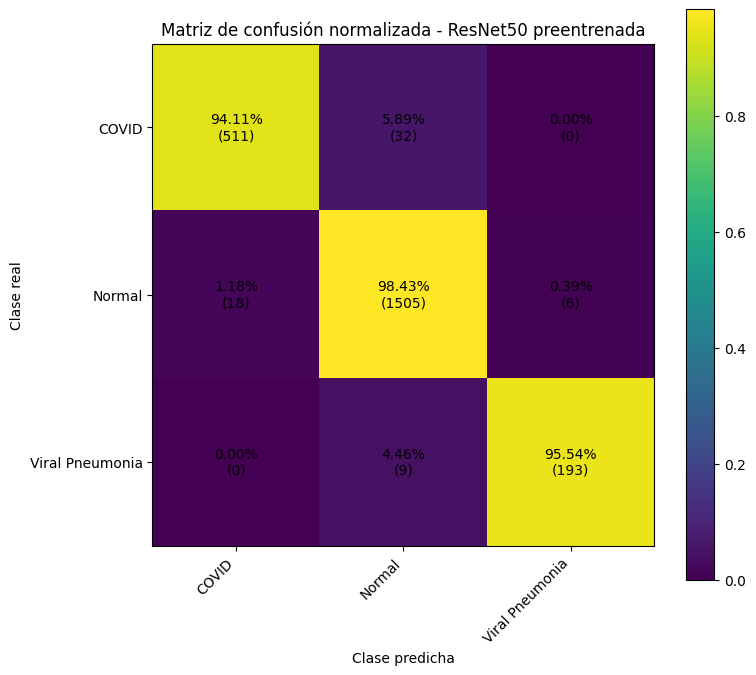

In [ ]:
matriz_confusion = confusion_matrix(
    etiquetas_reales,
    predicciones_modelo,
    labels=list(range(len(CLASES)))
)

matriz_confusion_normalizada = (
    matriz_confusion.astype("float")
    / np.maximum(matriz_confusion.sum(axis=1)[:, np.newaxis], 1)
)

figura, eje = plt.subplots(figsize=(8, 7))

imagen = eje.imshow(matriz_confusion_normalizada)

eje.set_title("Matriz de confusión normalizada - ResNet50 preentrenada")
eje.set_xlabel("Clase predicha")
eje.set_ylabel("Clase real")

eje.set_xticks(np.arange(len(CLASES)))
eje.set_yticks(np.arange(len(CLASES)))

eje.set_xticklabels(CLASES, rotation=45, ha="right")
eje.set_yticklabels(CLASES)

for i in range(len(CLASES)):
    for j in range(len(CLASES)):
        porcentaje = matriz_confusion_normalizada[i, j] * 100
        valor_absoluto = matriz_confusion[i, j]

        texto = f"{porcentaje:.2f}%\n({valor_absoluto})"

        eje.text(
            j,
            i,
            texto,
            ha="center",
            va="center"
        )

plt.colorbar(imagen)
plt.tight_layout()
plt.show()

Guardamos el modelo final

In [ ]:
modelo.save(str(RUTA_MODELO_FINAL))

print("Modelo final guardado en:")
print(RUTA_MODELO_FINAL)

Modelo final guardado en:
/content/drive/MyDrive/TFG/modelos resnet50 preentrenada 1 dataset/modelo_final_resnet50_preentrenada_1dataset.keras
